# P0 · Text-to-batch capstone

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.10 · Text-to-batch capstone

Split the stream before making windows, preserve the vocabulary, and verify the next-character shift.

**Prerequisites:** Read real model Python

**Predict:** When should the stream be split for this windowing example?

**Mental model:** The Python foundations now form a working preparation pipeline. Its final product is a set of input sequences paired with the characters that follow them.

<a id="python-read-change"></a>

<a data-compat-cell="p0-read-a-short-program-then-change-it"></a>

<a data-compat-cell="p0-practice"></a>

### Why this operation exists

The Python foundations now form a working preparation pipeline. Its final product is a set of input sequences paired with the characters that follow them.

Keep the vocabulary fixed while dividing the stream into training and validation portions. Here the vocabulary is an explicit character inventory for a small illustration.

Split the stream before constructing windows. Otherwise overlapping windows can accidentally share source positions across a split boundary.

Each window of three inputs needs four source positions to obtain its three shifted targets. Boundary checks are part of the data contract.

This small capstone checks preparation, not language-model quality. The training unit will explain evaluation and the actual dataset recipe.

### Follow the values

Build the vocabulary once and encode the full example text with it. The resulting integers retain the original order of positions.

Split the encoded stream after position eleven. Training and validation hold separate portions, and neither window builder crosses this boundary.

Choose two valid starts from the training portion. Each input window contains three positions, so the collection has two sequences of length three.

Shift each start and stop one place forward for the targets. The targets stay aligned with their corresponding input sequences.

Decode the first pair to check the meaning of the integers. Move both starts in the lab and confirm that every target remains the following character.

In [3]:
FRAMES.clear()
change = 0
text = "to be or not to be\n"
chars = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(chars)}
ids = [stoi[ch] for ch in text]
show("Vocabulary", chars)
cut = 12
train, valid = ids[:cut], ids[cut:]
show("Partition before windowing", {"train": train, "valid": valid})
size = 3
starts = [0, 1] if not change else [2, 3]
x = [train[i:i+size] for i in starts]
show("Input windows", x)
y = [train[i+1:i+size+1] for i in starts]
show("Target windows", y)
show("Decoded example", {"input": "".join(chars[i] for i in x[0]), "target": "".join(chars[i] for i in y[0])})
assert all(len(a) == len(b) == size and a[1:] == b[:-1] for a, b in zip(x, y))

Vocabulary: ["\n", " ", "b", "e", "n", "o", "r", "t"]
Partition before windowing: {"train": [7, 5, 1, 2, 3, 1, 5, 6, 1, 4, 5, 7], "valid": [1, 7, 5, 1, 2, 3, 0]}
Input windows: [[7, 5, 1], [5, 1, 2]]
Target windows: [[5, 1, 2], [1, 2, 3]]
Decoded example: {"input": "to ", "target": "o b"}


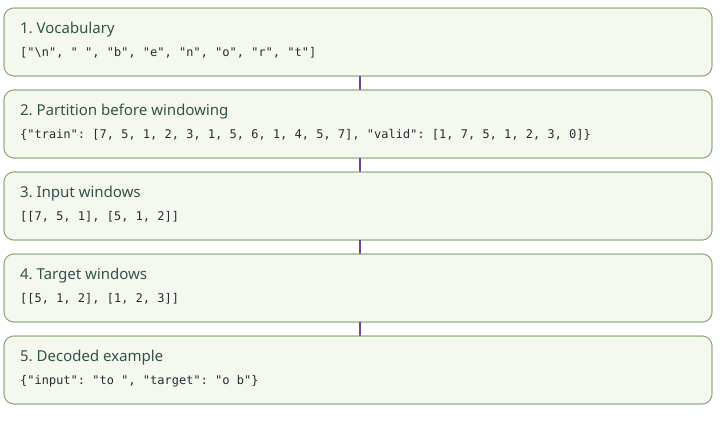

In [4]:
draw_trace()

### Read the implementation

Construct the vocabulary mapping before encoding. Keeping one mapping avoids giving the same ID different meanings in different splits.

A list comprehension creates one slice per chosen start. The starts are explicit here so you can inspect every source position.

A second comprehension applies the one-position target offset. Do not independently shuffle this target collection.

The assertion checks lengths and overlapping positions. A stronger boundary test also compares each pair against the original stream and its chosen start.

Test the last valid start and reject the first invalid one. Empty data and unknown characters should produce deliberate feedback instead of misleading batches.

### Change one thing

**Move both sampled starts forward**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
text = "to be or not to be\n"
chars = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(chars)}
ids = [stoi[ch] for ch in text]
show("Vocabulary", chars)
cut = 12
train, valid = ids[:cut], ids[cut:]
show("Partition before windowing", {"train": train, "valid": valid})
size = 3
starts = [0, 1] if not change else [2, 3]
x = [train[i:i+size] for i in starts]
show("Input windows", x)
y = [train[i+1:i+size+1] for i in starts]
show("Target windows", y)
show("Decoded example", {"input": "".join(chars[i] for i in x[0]), "target": "".join(chars[i] for i in y[0])})
assert all(len(a) == len(b) == size and a[1:] == b[:-1] for a, b in zip(x, y))

Vocabulary: ["\n", " ", "b", "e", "n", "o", "r", "t"]
Partition before windowing: {"train": [7, 5, 1, 2, 3, 1, 5, 6, 1, 4, 5, 7], "valid": [1, 7, 5, 1, 2, 3, 0]}
Input windows: [[1, 2, 3], [2, 3, 1]]
Target windows: [[2, 3, 1], [3, 1, 5]]
Decoded example: {"input": " be", "target": "be "}


### A useful distinction

Shuffling inputs independently from targets destroys supervision even when both tensors retain valid shapes.

### ✋ Your turn

For IDs [0,1,2,3,4], create the final valid length-3 input/target pair and put it in answer.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ([1, 2, 3], [2, 3, 4]), 'Shuffling inputs independently from targets destroys supervision even when both tensors retain valid shapes.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
ids = [0, 1, 2, 3, 4]
start = len(ids) - 3 - 1
answer = (ids[start:start+3], ids[start+1:start+4])

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ([1, 2, 3], [2, 3, 4]), 'Shuffling inputs independently from targets destroys supervision even when both tensors retain valid shapes.'
    print("✓ right:", answer)

✓ right: ([1, 2, 3], [2, 3, 4])


### Reconnect to the transformer

The training sampler performs the same slicing operation on a tensor of IDs. Stacking adds a batch axis without changing the next-character objective.

The current character model uses its full dataset vocabulary. Phyll adds tokenizer-specific special tokens and padding rules that are taught in its data lesson.

A character vocabulary inventory differs from fitting statistical preprocessing. In other tasks, learned preprocessing must be fitted on the training data according to the evaluation design.

You can now read the Python surrounding the tensor operations: imports, state, functions, comprehensions and the model's classes.

Continue to PyTorch. The next task is to preserve these meanings while operating on complete tensors of values.

```python
starts = torch.randint(len(data) - context, (batch_size,))
x = torch.stack([data[i:i+context] for i in starts])
y = torch.stack([data[i+1:i+context+1] for i in starts])
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** When should the stream be split for this windowing example?

<details><summary>Check your explanation</summary>

Before creating windows. Shuffling inputs independently from targets destroys supervision even when both tensors retain valid shapes.

</details>